# Convolutional Neural Networks

# Importar Librerías

In [4]:
import numpy as np
import os
import re
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [5]:
import keras
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential,Model
from tensorflow.keras.layers import Input
from keras.layers import Dense, Dropout, Flatten
#from keras.layers import Conv2D, MaxPooling2D
#from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    BatchNormalization, SeparableConv2D, MaxPooling2D, Activation, Flatten, Dropout, Dense, Conv2D
)
from keras.layers import LeakyReLU

# Cargar set de Imágenes

In [6]:
from skimage.transform import resize
import numpy as np
import matplotlib.pyplot as plt
import os
import re

dirname = os.path.join(os.getcwd(), 'animales')
imgpath = dirname + os.sep

images = []
directories = []
dircount = []

print("leyendo y redimensionando imagenes a 36x36 de ", imgpath)

for root, dirnames, filenames in os.walk(imgpath):
    valid_files = [f for f in filenames if re.search(r'\.(jpg|jpeg|png|bmp|tiff)$', f, re.IGNORECASE)]
    if not valid_files:
        continue
    
    print(f"Leyendo directorio: {root} ({len(valid_files)} imágenes)")
    directories.append(root)
    dircount.append(len(valid_files))
    
    cant = 0
    for filename in valid_files:
        cant += 1
        filepath = os.path.join(root, filename)
        try:
            image = plt.imread(filepath)
            if len(image.shape) == 3:
                if image.max() <= 1.0 and image.dtype != np.uint8:
                    image = (image * 255).astype(np.uint8)
                if image.shape[-1] == 4:
                    image = image[:, :, :3]
                image_resized = resize(image, (36, 36), anti_aliasing=True, clip=False, preserve_range=True)
                images.append(image_resized)
        except Exception as e:
            print(f"Error al leer {filename}: {e}")
        
        if cant % 100 == 0:
            print(f"  Procesadas {cant}/{len(valid_files)}...")

print('Directorios leidos:', len(directories))
print("Imagenes en cada directorio", dircount)
print('suma Total de imagenes en subdirs:', sum(dircount))

leyendo y redimensionando imagenes a 36x36 de  c:\Users\chato\Desktop\IA\proyecto 2\animales\
Leyendo directorio: c:\Users\chato\Desktop\IA\proyecto 2\animales\Araña (1500 imágenes)
  Procesadas 100/1500...
  Procesadas 200/1500...
  Procesadas 300/1500...
  Procesadas 400/1500...
  Procesadas 500/1500...
  Procesadas 600/1500...
  Procesadas 700/1500...
  Procesadas 800/1500...
  Procesadas 900/1500...
  Procesadas 1000/1500...
  Procesadas 1100/1500...
  Procesadas 1200/1500...
  Procesadas 1300/1500...
  Procesadas 1400/1500...
  Procesadas 1500/1500...
Leyendo directorio: c:\Users\chato\Desktop\IA\proyecto 2\animales\Ballena (1024 imágenes)
  Procesadas 100/1024...
  Procesadas 200/1024...
  Procesadas 300/1024...
  Procesadas 400/1024...
  Procesadas 500/1024...
  Procesadas 600/1024...
  Procesadas 700/1024...
  Procesadas 800/1024...
  Procesadas 900/1024...
  Procesadas 1000/1024...
Leyendo directorio: c:\Users\chato\Desktop\IA\proyecto 2\animales\Mono (1261 imágenes)
  Procesa

# Creamos las etiquetas

In [7]:
labels=[]
indice=0
for cantidad in dircount:
    for i in range(cantidad):
        labels.append(indice)
    indice=indice+1
print("Cantidad etiquetas creadas: ",len(labels))


Cantidad etiquetas creadas:  6350


In [8]:
animales=[]
indice=0
for directorio in directories:
    name = directorio.split(os.sep)
    print(indice , name[len(name)-1])
    animales.append(name[len(name)-1])
    indice=indice+1

0 Araña
1 Ballena
2 Mono
3 Pajaro
4 Rana


In [9]:
y = np.array(labels)
X = np.array(images, dtype=np.uint8) #convierto de lista a numpy



# Find the unique numbers from the train labels
classes = np.unique(y)
nClasses = len(classes)
print('Total number of outputs : ', nClasses)
print('Output classes : ', classes)

Total number of outputs :  5
Output classes :  [0 1 2 3 4]


# Creamos Sets de Entrenamiento y Test

In [10]:
train_X,test_X,train_Y,test_Y = train_test_split(X,y,test_size=0.2)
print('Training data shape : ', train_X.shape, train_Y.shape)
print('Testing data shape : ', test_X.shape, test_Y.shape)

Training data shape :  (5080, 36, 36, 3) (5080,)
Testing data shape :  (1270, 36, 36, 3) (1270,)


Text(0.5, 1.0, 'Ground Truth : 3')

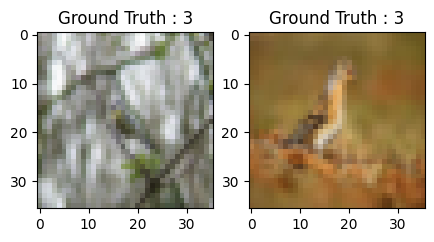

In [11]:
plt.figure(figsize=[5,5])

# Display the first image in training data
plt.subplot(121)
plt.imshow(train_X[0,:,:], cmap='gray')
plt.title("Ground Truth : {}".format(train_Y[0]))

# Display the first image in testing data
plt.subplot(122)
plt.imshow(test_X[0,:,:], cmap='gray')
plt.title("Ground Truth : {}".format(test_Y[0]))

# Preprocesamos las imagenes

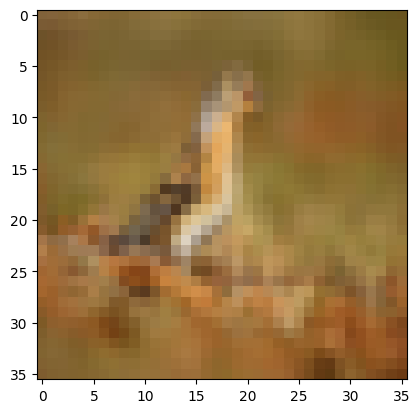

In [12]:
train_X = train_X.astype('float32')
test_X = test_X.astype('float32')
train_X = train_X/255.
test_X = test_X/255.
plt.imshow(test_X[0,:,:])

## Hacemos el One-hot Encoding para la red

In [13]:
# Change the labels from categorical to one-hot encoding
train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)

# Display the change for category label using one-hot encoding
print('Original label:', train_Y[0])
print('After conversion to one-hot:', train_Y_one_hot[0])

Original label: 3
After conversion to one-hot: [0. 0. 0. 1. 0.]


# Creamos el Set de Entrenamiento y Validación

In [14]:
#Mezclar todo y crear los grupos de entrenamiento y testing
train_X,valid_X,train_label,valid_label = train_test_split(train_X, train_Y_one_hot, test_size=0.2, random_state=13)

In [15]:
print(train_X.shape,valid_X.shape,train_label.shape,valid_label.shape)

(4064, 36, 36, 3) (1016, 36, 36, 3) (4064, 5) (1016, 5)


# Creamos el modelo de CNN

In [16]:
#declaramos variables con los parámetros de configuración de la red
INIT_LR = 1e-3 # Valor inicial de learning rate. El valor 1e-3 corresponde con 0.001
epochs = 20 # Cantidad de iteraciones completas al conjunto de imagenes de entrenamiento
batch_size = 64 # cantidad de imágenes que se toman a la vez en memoria

In [17]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, GlobalAveragePooling2D, Dense, BatchNormalization, Activation
import tensorflow as tf

animals_model = Sequential([
    Input(shape=(36, 36, 3)),
    
    # 1. Capas de Aumentación de Datos Avanzada
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.15),
    
    # Bloque Convolucional 1
    Conv2D(32, kernel_size=(3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(32, kernel_size=(3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),
    
    # Bloque Convolucional 2
    Conv2D(64, kernel_size=(3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(64, kernel_size=(3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    
    # Bloque Convolucional 3
    Conv2D(128, kernel_size=(3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(128, kernel_size=(3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),
    
    # Bloque Convolucional 4
    Conv2D(256, kernel_size=(3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.4),
    
    # Clasificador Basado en Global Average Pooling (Evita Overfitting)
    GlobalAveragePooling2D(),
    Dense(256),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),
    Dense(nClasses, activation='softmax')
])


In [18]:
animals_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 36, 36, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 36, 36, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 36, 36, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 36, 36, 3)      │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 36, 36, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 36, 36, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 36, 36, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 36, 36, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 18, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 18, 18, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 18, 18, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 9, 9, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 9, 9, 128)      │           51

 Total params: 653,093 (2.49 MB)

 Trainable params: 651,173 (2.48 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [19]:
animals_model.compile(loss=keras.losses.categorical_crossentropy, optimizer=tf.keras.optimizers.Adam(learning_rate=INIT_LR),metrics=['accuracy'])

# Entrenamos el modelo: Aprende a clasificar imágenes

In [20]:
# Habilitar entrenamiento desde cero
force_retrain = True

import os
import keras
from sklearn.utils import class_weight

model_path = "animals_36_V3.keras"
model_path_legacy = "animals_36_V3.h5"
loaded_from_disk = False

if not force_retrain:
    if os.path.exists(model_path):
        print(f"Cargando modelo guardado (36x36) desde: {model_path}")
        animals_model = keras.models.load_model(model_path)
        loaded_from_disk = True
        print("¡Modelo cargado exitosamente del disco!")

if not loaded_from_disk:
    print("Iniciando entrenamiento del modelo 36x36 con regularización y class weights...")
    
    # 1. Calcular class weights automáticos
    train_labels_ints = np.argmax(train_label, axis=1)
    class_weights = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(train_labels_ints),
        y=train_labels_ints
    )
    class_weights_dict = dict(enumerate(class_weights))
    print(f"Pesos de clase calculados: {class_weights_dict}")
    
    # Callbacks (EarlyStopping de 8 épocas y ReduceLROnPlateau)
    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
    ]
    
    # Entrenamos por las épocas definidas pasándole los pesos de clase
    animals_train = animals_model.fit(
        train_X, train_label, 
        batch_size=batch_size,
        epochs=epochs,
        verbose=1,
        validation_data=(valid_X, valid_label),
        callbacks=callbacks,
        class_weight=class_weights_dict
    )
    
    # Guardar los nuevos modelos entrenados a 128x128
    print("Guardando nuevo modelo optimizado...")
    animals_model.save(model_path)
    animals_model.save(model_path_legacy)
    print("Modelos guardados exitosamente como animals_128_V3.keras y animals_128_V3.h5!")
else:
    animals_train = None


Iniciando entrenamiento del modelo 36x36 con regularización y class weights...
Pesos de clase calculados: {0: np.float64(0.8674493062966916), 1: np.float64(1.2185907046476763), 2: np.float64(1.005940594059406), 3: np.float64(0.9745803357314149), 4: np.float64(0.993643031784841)}
Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.4892 - loss: 1.3110 - val_accuracy: 0.3071 - val_loss: 1.4937 - learning_rate: 0.0010
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 108s 775ms/step - accuracy: 0.5667 - loss: 1.0735 - val_accuracy: 0.3179 - val_loss: 1.4553 - learning_rate: 0.0010
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 79s 728ms/step - accuracy: 0.6304 - loss: 0.9604 - val_accuracy: 0.3622 - val_loss: 1.4827 - learning_rate: 0.0010
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.6503 - loss: 0.8848 - val_accuracy: 0.4065 - val_loss: 1.2225 - learning_rate: 0.0010
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.6671 - loss: 0.8440 - val_accuracy: 0.4429 - v

Modelos guardados exitosamente como animals_128_V3.keras y animals_128_V3.h5!


In [21]:
# guardamos la red, para reutilizarla en el futuro, sin tener que volver a entrenar
print("Guardando modelo en formato moderno .keras y legacy .h5...")
animals_model.save("animals_V3.keras")
animals_model.save("animals_V3.h5")
print("¡Modelo guardado exitosamente como animals_V3.keras y animals_V3.h5!")


Guardando modelo en formato moderno .keras y legacy .h5...


¡Modelo guardado exitosamente como animals_V3.keras y animals_V3.h5!


## Historial de Entrenamiento

Graficamos la precisión y pérdida del entrenamiento. Si el modelo se cargó directamente del disco, esta sección se saltará de forma segura.

In [22]:
test_eval = animals_model.evaluate(test_X, test_Y_one_hot, verbose=1)

40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 227ms/step - accuracy: 0.7740 - loss: 0.5741


In [23]:
print('Test loss:', test_eval[0])
print('Test accuracy:', test_eval[1])

Test loss: 0.5740689635276794
Test accuracy: 0.7740157246589661


In [24]:
if 'animals_train' in globals() and animals_train is not None:
    animals_train.history
else:
    print("Historial de entrenamiento no disponible (modelo cargado directamente desde disco).")

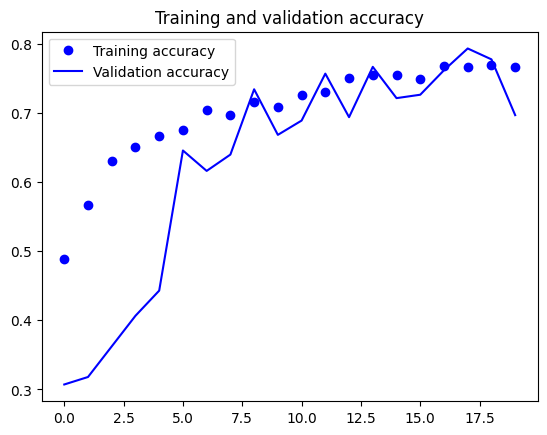

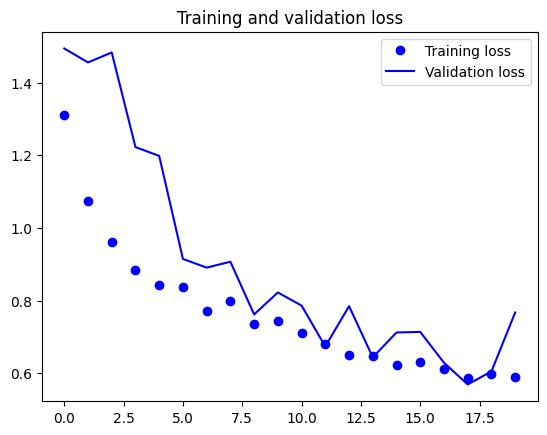

In [25]:
if 'animals_train' in globals() and animals_train is not None:
    accuracy = animals_train.history['accuracy']
    val_accuracy = animals_train.history['val_accuracy']
    loss = animals_train.history['loss']
    val_loss = animals_train.history['val_loss']
    epochs_range = range(len(accuracy))
    
    plt.plot(epochs_range, accuracy, 'bo', label='Training accuracy')
    plt.plot(epochs_range, val_accuracy, 'b', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.legend()
    plt.figure()
    plt.plot(epochs_range, loss, 'bo', label='Training loss')
    plt.plot(epochs_range, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()
    plt.show()
else:
    print("El modelo fue cargado directamente del disco, por lo que no hay historial de entrenamiento disponible para graficar.")

In [26]:
predicted_classes2 = animals_model.predict(test_X)

40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 286ms/step


In [27]:
predicted_classes=[]
for predicted_animal in predicted_classes2:
    predicted_classes.append(predicted_animal.tolist().index(max(predicted_animal)))
predicted_classes=np.array(predicted_classes)

In [28]:
predicted_classes.shape, test_Y.shape

((1270,), (1270,))

# Aprendamos de los errores: Qué mejorar

Found 983 correct labels


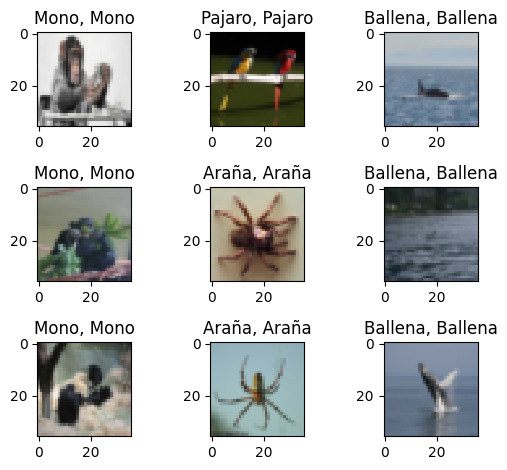

In [29]:
correct = np.where(predicted_classes==test_Y)[0]
print("Found %d correct labels" % len(correct))
for i, idx in enumerate(correct[0:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test_X[idx], interpolation='none')
    plt.title("{}, {}".format(animales[predicted_classes[idx]],
                                                    animales[test_Y[idx]]))

    plt.tight_layout()

Found 287 incorrect labels


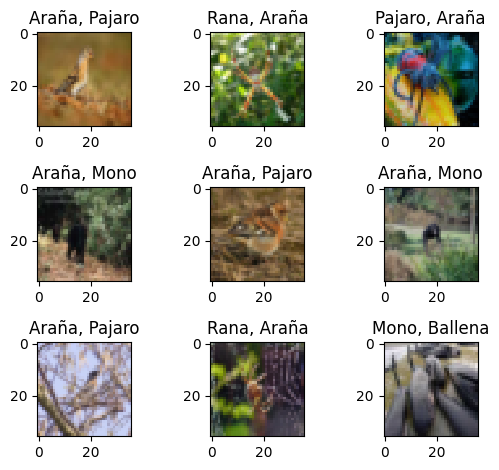

In [30]:
incorrect = np.where(predicted_classes!=test_Y)[0]
print("Found %d incorrect labels" % len(incorrect))
for i, idx in enumerate(incorrect[0:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test_X[idx].reshape(36,36,3), cmap='gray', interpolation='none')
    plt.title("{}, {}".format(animales[predicted_classes[idx]],
                                                    animales[test_Y[idx]]))
    plt.tight_layout()

In [31]:
target_names = ["Class {}".format(i) for i in range(nClasses)]
print(classification_report(test_Y, predicted_classes, target_names=target_names))

              precision    recall  f1-score   support

     Class 0       0.66      0.75      0.71       318
     Class 1       0.94      0.90      0.92       210
     Class 2       0.75      0.73      0.74       236
     Class 3       0.79      0.69      0.74       244
     Class 4       0.80      0.81      0.81       262

    accuracy                           0.77      1270
   macro avg       0.79      0.78      0.78      1270
weighted avg       0.78      0.77      0.78      1270



## Matriz de confusion

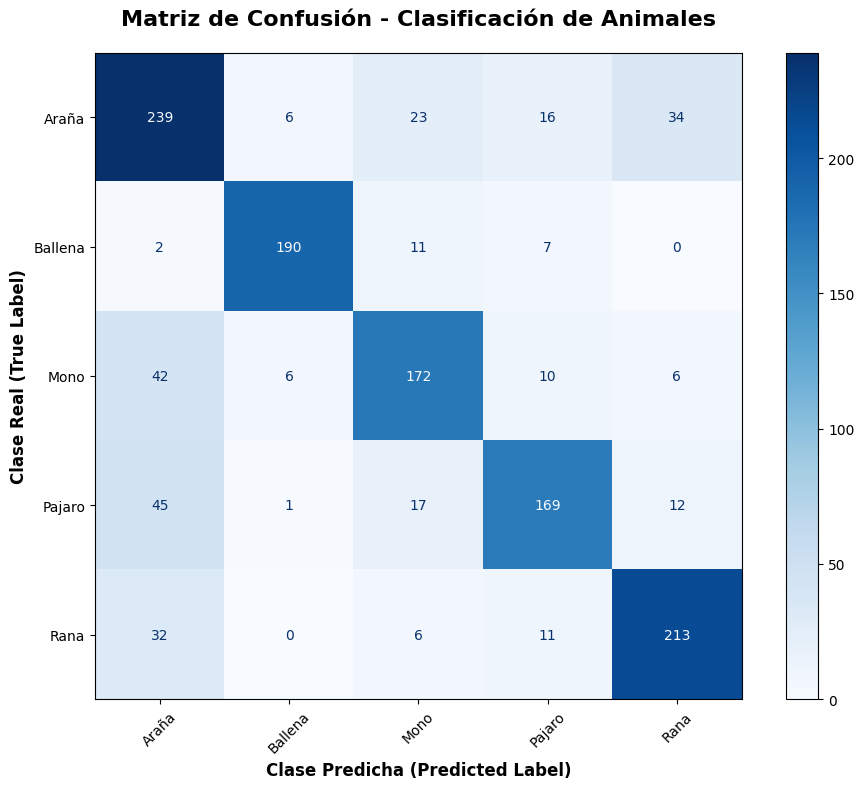

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 1. Calcular la matriz de confusión usando las etiquetas reales y predichas
cm = confusion_matrix(test_Y, predicted_classes)

# 2. Graficar la matriz de confusión de manera visual y profesional
try:
    import seaborn as sns
    plt.figure(figsize=(10, 8))
    # Usamos una paleta de colores azul sofisticada y premium
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=animales, yticklabels=animales,
                annot_kws={"size": 12, "weight": "bold"})
    plt.title('Matriz de Confusión - Clasificación de Animales', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Clase Real (True Label)', fontsize=12, fontweight='bold')
    plt.xlabel('Clase Predicha (Predicted Label)', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()
except ImportError:
    # Si seaborn no está instalado, usamos la visualización nativa de scikit-learn
    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=animales)
    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
    plt.title('Matriz de Confusión - Clasificación de Animales', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Clase Real (True Label)', fontsize=12, fontweight='bold')
    plt.xlabel('Clase Predicha (Predicted Label)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [37]:
from skimage.transform import resize
import numpy as np
import matplotlib.pyplot as plt
import os
import keras

# Intentamos cargar el modelo guardado de 36x36 del disco para no tener que volver a entrenar
model_path = "animals_36_V3.keras"
model_path_legacy = "animals_36_V3.h5"

if os.path.exists(model_path):
    print(f"Cargando modelo guardado (36x36) desde: {model_path}")
    animals_model = keras.models.load_model(model_path)
    print("¡Modelo de 36x36 cargado exitosamente!")
elif os.path.exists(model_path_legacy):
    print(f"Cargando modelo guardado (legacy 36x36) desde: {model_path_legacy}")
    animals_model = keras.models.load_model(model_path_legacy)
    print("¡Modelo de 36x36 cargado exitosamente!")
else:
    print("ADVERTENCIA: No se encontró un modelo de 36x36 guardado en el disco. Se usará el modelo en memoria activa.")

import re

test2_dir = r'C:\Users\chato\Desktop\IA\proyecto 2\test'
filenames = []
if os.path.exists(test2_dir):
    for f in os.listdir(test2_dir):
        if re.search(r'\.(jpg|jpeg|png|bmp|tiff|webp|avif)$', f, re.IGNORECASE):
            filenames.append(os.path.join(test2_dir, f))

images = []

for filepath in filenames:
    if not os.path.exists(filepath):
        print(f"Archivo no encontrado: {filepath}")
        continue
    image = plt.imread(filepath)
    
    # Si la imagen se lee en rango [0.0, 1.0], la escalamos a [0, 255]
    if image.max() <= 1.0 and image.dtype != np.uint8:
        image = (image * 255).astype(np.uint8)
        
    # Manejar canales de imagen: RGBA -> RGB o Escala de grises -> RGB
    if len(image.shape) == 2:
        image = np.stack([image] * 3, axis=-1)
    elif image.shape[-1] == 4:
        image = image[:, :, :3]
        
    image_resized = resize(image, (36, 36), anti_aliasing=True, clip=False, preserve_range=True)
    images.append(image_resized)

if len(images) > 0:
    X = np.array(images, dtype=np.uint8) #convierto de lista a numpy
    test_X = X.astype('float32')
    test_X = test_X / 255.

    predicted_classes2 = animals_model.predict(test_X)

    predicted_classes = []
    for predicted_animal in predicted_classes2:
        predicted_classes.append(predicted_animal.tolist().index(max(predicted_animal)))
    predicted_classes = np.array(predicted_classes)

    for i, img_tagged in enumerate(predicted_classes2):
        confidence = max(img_tagged) * 100
        predicted_idx = img_tagged.tolist().index(max(img_tagged))
        print(f"{filenames[i]} -> Predicción: {animales[predicted_idx]} ({confidence:.2f}%)")
else:
    print("No hay imágenes válidas para evaluar.")


Cargando modelo guardado (36x36) desde: animals_36_V3.keras
¡Modelo de 36x36 cargado exitosamente!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 908ms/step
C:\Users\chato\Desktop\IA\proyecto 2\test\p1.jpg -> Predicción: Pajaro (71.43%)
C:\Users\chato\Desktop\IA\proyecto 2\test\p2.jpg -> Predicción: Pajaro (58.44%)
C:\Users\chato\Desktop\IA\proyecto 2\test\p3.jpg -> Predicción: Pajaro (87.56%)
C:\Users\chato\Desktop\IA\proyecto 2\test\p4.jpg -> Predicción: Rana (85.42%)
C:\Users\chato\Desktop\IA\proyecto 2\test\p5.jpg -> Predicción: Pajaro (81.46%)
